In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv('../data/clean_dataset.csv')

data = np.array(df).reshape((df.shape[0], df.shape[1], 1))

In [5]:
import pickle

def normalizeData(data) :
  scaler = MinMaxScaler(feature_range=(0,1))
  data_scaled = np.zeros((data.shape[0], data.shape[1], 1))
  
  for i in range(data.shape[1]) :
    data_scaled[:,i] = scaler.fit_transform(data[:,i])
    
    with open(f'../scalers/scaler_{i+1}.pkl', 'wb') as file:
      pickle.dump(scaler, file)
  
  return data_scaled

data_scaled = normalizeData(data)

In [6]:
train_split = round(len(data_scaled)*0.80) 
test_split = round(len(data_scaled)*0.10)

data_train = data_scaled[:train_split]
data_val = data_scaled[train_split:-test_split]
data_test = data_scaled[-test_split:]

In [141]:
n_feature = 0
n_timestep = 30
n_output = 31

def createXY(data, n_timestep, n_feature):
  dataX = []
  dataY = []
  for i in range(n_timestep, len(data) - n_output):
    dataX.append(data[i-n_timestep : i, n_feature])
    dataY.append(data[i : i+n_output, n_feature])
  dataX = np.array(dataX)
  dataY = np.array(dataY)
  dataY = dataY.reshape(dataY.shape[0], dataY.shape[1])
  return dataX, dataY

trainX, trainY = createXY(data_train, n_timestep, n_feature)
testX, testY = createXY(data_test, n_timestep, n_feature)
valX, valY = createXY(data_val, n_timestep, n_feature)

input_shape = trainX[0].shape

In [39]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=input_shape),
  tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=64, return_sequences=True)),
  tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=64)),
  tf.keras.layers.Dense(units=n_output),
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
              loss='mean_squared_error')

history = model.fit(trainX, trainY, 
                    epochs=30, 
                    batch_size=16, 
                    validation_data=(valX, valY), 
                    verbose=1,)

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.1724 - val_loss: 0.0550
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1661 - val_loss: 0.0510
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1467 - val_loss: 0.0465
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1361 - val_loss: 0.0410
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1278 - val_loss: 0.0340
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1044 - val_loss: 0.0258
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0856 - val_loss: 0.0172
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0668 - val_loss: 0.0102
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0435 - val_loss: 0.0061
Epoch 10/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0326 - val_loss: 0.0039
Epoch 11/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0256 - val_loss: 0.0025
Epoch 12/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.

In [40]:
if __name__ == '__main__':
    model.save(f"../models/model_{n_feature+1}.h5")

In [162]:
# Memuat scaler dari file .pkl
with open('../scalers/scaler_1.pkl', 'rb') as file:
    scaler = pickle.load(file)

In [163]:
# Memuat model dari file .h5
model = tf.keras.models.load_model('../models/model_1.h5')

In [166]:
trainX[31:32].shape

(1, 30, 1)

In [164]:
scaler.inverse_transform(trainX[31])

array([[32400.],
       [32400.],
       [33440.],
       [33190.],
       [32400.],
       [31690.],
       [31770.],
       [32010.],
       [31490.],
       [31220.],
       [31400.],
       [32730.],
       [31900.],
       [31100.],
       [29930.],
       [31600.],
       [31640.],
       [30720.],
       [30720.],
       [30420.],
       [30360.],
       [30550.],
       [30950.],
       [29840.],
       [29080.],
       [30690.],
       [30590.],
       [30260.],
       [30990.],
       [30990.]])

In [134]:
predictions = model.predict(trainX[31:32])

mse = np.mean((predictions - trainY[31:32]) **2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [135]:
mse

0.0004413881850383868

In [137]:
contoh = [
  [31940],
  [33210],
  [33210],
  [32120],
  [31700],
  [31700],
  [31280],
  [31080],
  [30770],
  [30520],
  [30750],
  [30680],
  [30060],
  [29970],
  [27440],
  [28290],
  [28020],
  [27810],
  [26610],
  [26450],
  [28370],
  [26980],
  [26580],
  [26960],
  [27200],
  [27720],
  [25430],
  [28170],
  [27840],
  [27180],
]

In [115]:
with open('../scalers/scaler_1.pkl', 'rb') as file:
    scaler = pickle.load(file)

# Transform data using the loaded scaler
scaled_data = scaler.transform(contoh)

In [130]:
test = scaler.inverse_transform(testX[50])

In [131]:
test

array([[54530.],
       [53200.],
       [49950.],
       [50690.],
       [51170.],
       [48930.],
       [49540.],
       [48460.],
       [48130.],
       [46490.],
       [47780.],
       [48890.],
       [47530.],
       [48210.],
       [47290.],
       [47710.],
       [49160.],
       [49250.],
       [47780.],
       [46360.],
       [45420.],
       [46010.],
       [47950.],
       [47600.],
       [48040.],
       [48180.],
       [46740.],
       [47310.],
       [45420.],
       [45910.]])

In [138]:
scaled_data = scaled_data.reshape(1,-1,1)

In [132]:
coba = testX[50:51].reshape(1,-1,1)

In [133]:
coba

array([[[0.69606399],
        [0.66806988],
        [0.59966323],
        [0.6152389 ],
        [0.62534203],
        [0.57819406],
        [0.59103347],
        [0.56830141],
        [0.5613555 ],
        [0.52683646],
        [0.55398863],
        [0.57735214],
        [0.54872658],
        [0.56303936],
        [0.54367502],
        [0.55251526],
        [0.58303515],
        [0.58492949],
        [0.55398863],
        [0.52410019],
        [0.50431488],
        [0.51673332],
        [0.55756683],
        [0.55019996],
        [0.55946117],
        [0.56240791],
        [0.53209851],
        [0.54409598],
        [0.50431488],
        [0.5146285 ]]])

In [139]:
scaled_data.shape

(1, 30, 1)

In [140]:
predict = model.predict(scaled_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [141]:
data_asli = scaler.inverse_transform(predict)

In [142]:
data_asli

array([[29482.836, 29813.74 , 28933.53 , 29819.191, 28753.572, 29301.416,
        30307.969, 29357.281, 29991.389, 29342.387, 29779.79 , 29093.59 ,
        30078.535, 29957.38 , 28947.559, 29464.504, 28941.324, 29405.855,
        29131.326, 30107.283, 29011.97 , 29511.588, 29403.379, 29321.51 ,
        29176.   , 29364.988, 29586.053, 29710.486, 29193.584, 29137.314,
        29410.68 ]], dtype=float32)

In [644]:
model.evaluate(testX, testY)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - loss: 0.0012


0.0011058320524170995

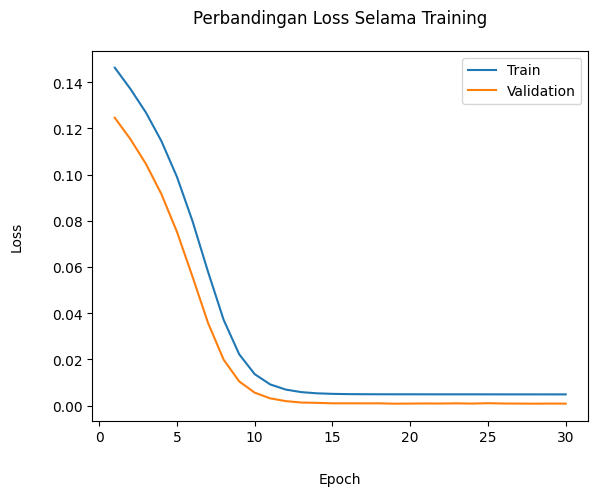

In [708]:
epochs_range = range(1, len(history.history['loss']) + 1)
plt.plot(epochs_range, history.history['loss'])
plt.plot(epochs_range, history.history['val_loss'])
plt.title('Perbandingan Loss Selama Training', pad=20)
plt.xlabel('Epoch', labelpad=20)
plt.ylabel('Loss', labelpad=20)
plt.legend(['Train', 'Validation'])
plt.show()

In [611]:
predictionsOnTrain = model.predict(trainX)
predictionsOnVal = model.predict(valX)
predictionsOnTest = model.predict(testX)

mse1 = np.mean((predictionsOnTrain - trainY) ** 2)
mse2 = np.mean((predictionsOnVal - valY) **2)
mse3 = np.mean((predictionsOnTest - testY) **2)

print(f'\nLoss pada data training: {mse1}')
print(f'Loss pada data validation: {mse2}')
print(f'Loss pada data testing: {mse3}')

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Loss pada data training: 0.004962563599264817
Loss pada data validation: 0.0010180138127258184
Loss pada data testing: 0.0020578766446106363


In [57]:
predictions = model.predict(testX)

mse = np.mean((testY - predictions) **2)
mae = np.mean(abs(testY - predictions))
rmse = np.sqrt(np.mean((predictions - testY) ** 2))
mape = 100 * np.mean(abs((predictions - testY) / testY))

print(f'MSE pada data testing: {mse}')
print(f'MAE pada data testing: {mae}')
print(f'RMSE pada data testing: {rmse}')
print(f'MAPE pada data testing: {mape}')

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None

In [58]:
model.predict(trainX[200:202])

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None

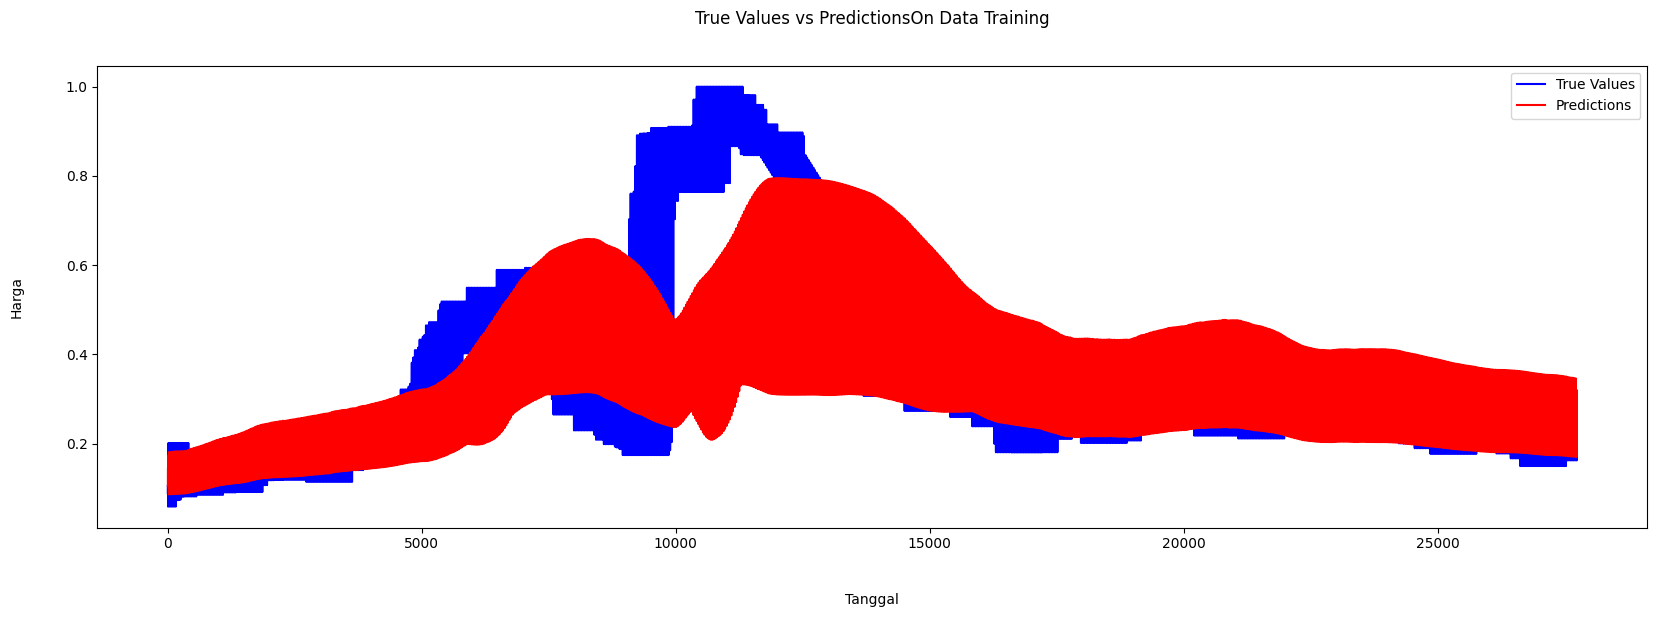

In [581]:
# Plot nilai prediksi dan nilai sebenarnya

plt.figure(figsize=(20, 6))
plt.plot(trainY.flatten(), label='True Values', color='blue')
plt.plot(predictionsOnTrain.flatten(), label='Predictions', color='red')

plt.xlabel('Tanggal', labelpad=30)
plt.ylabel('Harga', labelpad=30)
plt.title('True Values vs PredictionsOn Data Training', pad=30)
plt.legend()

plt.show()

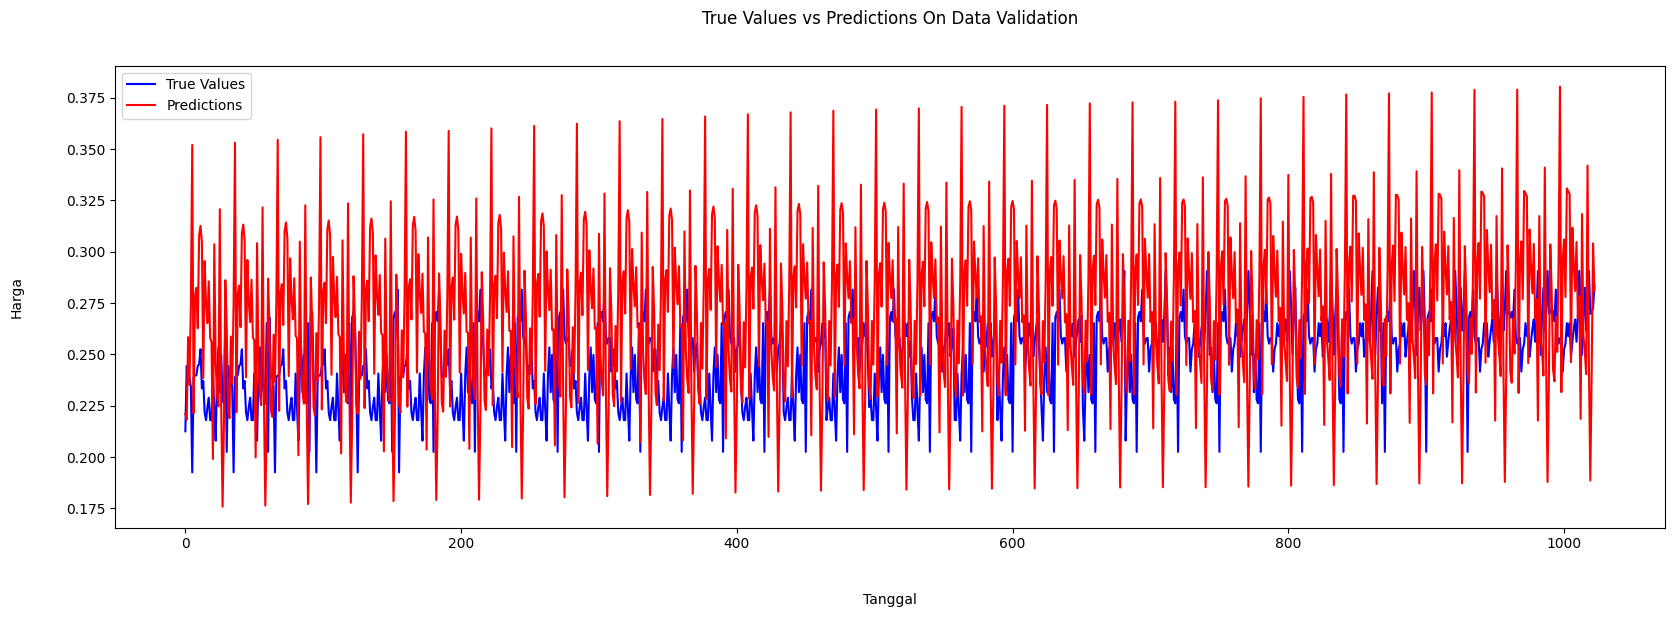

In [582]:
# Plot nilai prediksi dan nilai sebenarnya

plt.figure(figsize=(20, 6))
plt.plot(valY.flatten(), label='True Values', color='blue')
plt.plot(predictionsOnVal.flatten(), label='Predictions', color='red')

plt.xlabel('Tanggal', labelpad=30)
plt.ylabel('Harga', labelpad=30)
plt.title('True Values vs Predictions On Data Validation', pad=30)
plt.legend()

plt.show()

In [583]:
testY.flatten()[:1000]

array([0.34059946, 0.35785649, 0.33333333, 0.34604905, 0.36693915,
       0.34786558, 0.35149864, 0.35603996, 0.34514078, 0.36603088,
       0.36239782, 0.35603996, 0.35603996, 0.34604905, 0.38510445,
       0.36966394, 0.38601272, 0.35331517, 0.35331517, 0.35876476,
       0.36148955, 0.35422343, 0.35059037, 0.36330609, 0.36784741,
       0.35967302, 0.35059037, 0.36330609, 0.36784741, 0.38782925,
       0.36784741, 0.35785649, 0.33333333, 0.34604905, 0.36693915,
       0.34786558, 0.35149864, 0.35603996, 0.34514078, 0.36603088,
       0.36239782, 0.35603996, 0.35603996, 0.34604905, 0.38510445,
       0.36966394, 0.38601272, 0.35331517, 0.35331517, 0.35876476,
       0.36148955, 0.35422343, 0.35059037, 0.36330609, 0.36784741,
       0.35967302, 0.35059037, 0.36330609, 0.36784741, 0.38782925,
       0.36784741, 0.3524069 , 0.33333333, 0.34604905, 0.36693915,
       0.34786558, 0.35149864, 0.35603996, 0.34514078, 0.36603088,
       0.36239782, 0.35603996, 0.35603996, 0.34604905, 0.38510

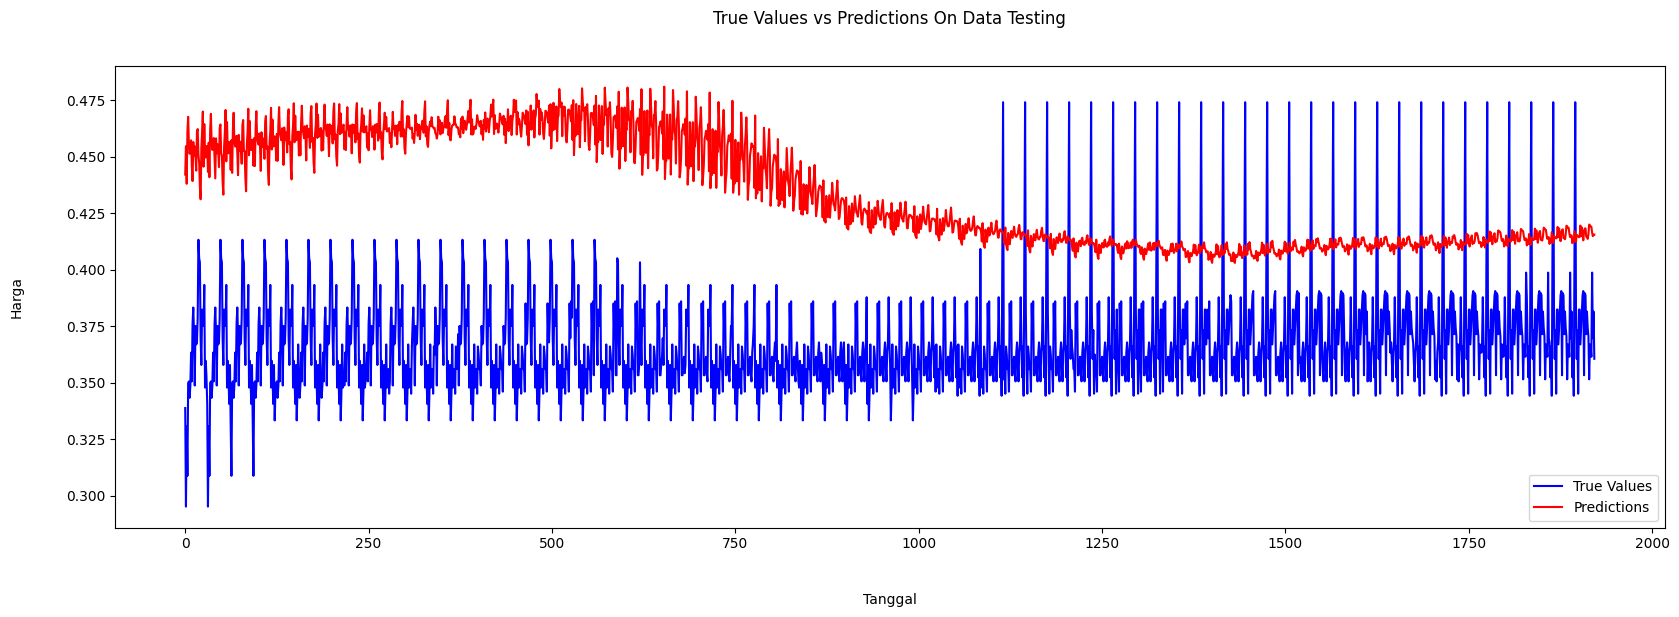

In [649]:
# Plot nilai prediksi dan nilai sebenarnya

plt.figure(figsize=(20, 6))
plt.plot(testY.flatten(), label='True Values', color='blue')
plt.plot(predictionsOnTest.flatten(), label='Predictions', color='red')

plt.xlabel('Tanggal', labelpad=30)
plt.ylabel('Harga', labelpad=30)
plt.title('True Values vs Predictions On Data Testing', pad=30)
plt.legend()

plt.show()

1922

In [694]:
if __name__ == '__main__':
    model.save("../models/model_8.h5")

In [195]:
dataTrainAnn = dataTrain.reshape((dataTrain.shape[0], dataTrain.shape[1]))
dataTestAnn = dataTest.reshape((dataTest.shape[0], dataTest.shape[1]))
dataValAnn = dataVal.reshape((dataVal.shape[0], dataVal.shape[1]))

In [196]:
dataValAnn.shape

(124, 9)

In [205]:
def createXY_ann(data, n_past, n_feature):
  dataX = []
  dataY = []
  for i in range(n_past, len(data)-31):
    dataX.append(data[i - n_past:i, n_feature])
    dataY.append(data[i+31, n_feature])
  dataX = np.array(dataX)
  dataY = np.array(dataY)
  return dataX, dataY

trainX_ann, trainY_ann = createXY_ann(dataTrainAnn, 20, 0)
testX_ann, testY_ann = createXY_ann(dataTestAnn, 20, 0)
valX_ann, valY_ann = createXY_ann(dataValAnn, 20, 0)

input_shape_ann = trainX_ann[0].shape
input_shape_ann

(20,)

In [206]:
testX_ann.shape

(72, 20)

In [207]:
# Build the ANN model
model_ann = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=input_shape_ann),
  tf.keras.layers.Dense(units=256, activation='relu'),
  tf.keras.layers.Dense(units=1, activation='relu'),
])

model_ann.compile(optimizer='adam', 
                  loss='mean_squared_error')

model_ann.fit(trainX_ann, 
              trainY_ann, 
              epochs=10, 
              batch_size=32, 
              validation_data=(valX_ann, valY_ann))

predictions_ann = model_ann.predict(testX_ann)

mse_ann = np.mean((predictions_ann - testY_ann) ** 2)
print("Loss (ANN):", mse_ann)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0402 - val_loss: 0.0084
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0212 - val_loss: 0.0069
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0190 - val_loss: 0.0121
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0206 - val_loss: 0.0061
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0203 - val_loss: 0.0116
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0188 - val_loss: 0.0100
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0197 - val_loss: 0.0115
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0197 - val_loss: 0.0118
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0184 - val_loss: 0.0095
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0198 - val_loss: 0.0115
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Loss (ANN): 0.042717686143077915


In [202]:
testX_ann[0]

array([0.27611262, 0.26702997, 0.27338783, 0.27611262, 0.26612171,
       0.27611262, 0.27611262, 0.28247048, 0.22797457, 0.27338783,
       0.24523161, 0.26521344, 0.26612171, 0.2688465 , 0.29881926,
       0.26612171, 0.27792916, 0.27247956, 0.27066303, 0.27611262])

In [203]:
model_ann.predict(testX_ann[0:2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


array([[0.30491993],
       [0.30240247]], dtype=float32)

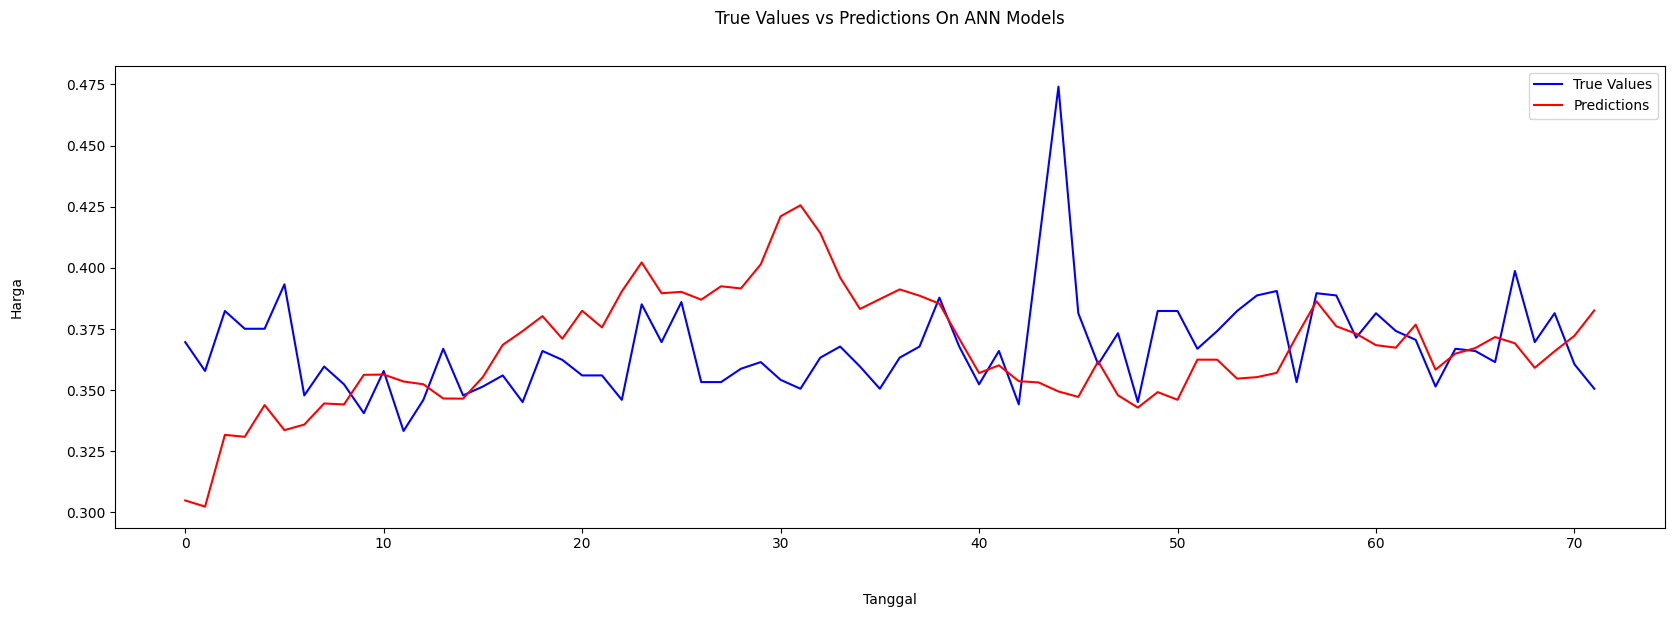

In [204]:
# Plot nilai prediksi dan nilai sebenarnya

plt.figure(figsize=(20, 6))
plt.plot(testY, label='True Values', color='blue')
plt.plot(predictions_ann, label='Predictions', color='red')

plt.xlabel('Tanggal', labelpad=30)
plt.ylabel('Harga', labelpad=30)
plt.title('True Values vs Predictions On ANN Models', pad=30)
plt.legend()

plt.show()